<a href="https://colab.research.google.com/github/ryanaxiom/Applied-ML/blob/main/code/Day06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student Instructions**: Before you begin, click **File > Save a copy in Drive** so you do not lose your work!

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print(pd.__version__)
print(np.__version__)

url = ("https://raw.githubusercontent.com/ryanaxiom/Applied-ML/main/data/carnegie_data.csv")

carnegie_raw = pd.read_csv(url, encoding="cp1252")
carnegie = carnegie_raw.copy()
carnegie["research"] = carnegie["serd"] + carnegie["nonserd"]
d = carnegie[carnegie["research"].notna()].copy()
d["med_yn"] = (d["medical"] == 1 ).astype(int)
x = d["fallenr20"]
y = d["research"]

model = LinearRegression()
model.fit(d[["fallenr20"]],y)

2.2.3
2.1.3


In [6]:
b1, b0 = model.coef_[0], model.intercept_

In [7]:
b1, b0

(np.float64(10.617996540768235), np.float64(53224.0057142553))

In [8]:
model.predict([[11254],[11958]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([172718.93878406, 180194.00834876])

In [11]:
pred = pd.DataFrame({"fallenr20": [11254,11958]})

In [12]:
model.predict(pred)

array([172718.93878406, 180194.00834876])

In [13]:
yhat = b0 + b1 * x
np.sqrt(np.mean((y-yhat)**2))

np.float64(347365.52905296)

2

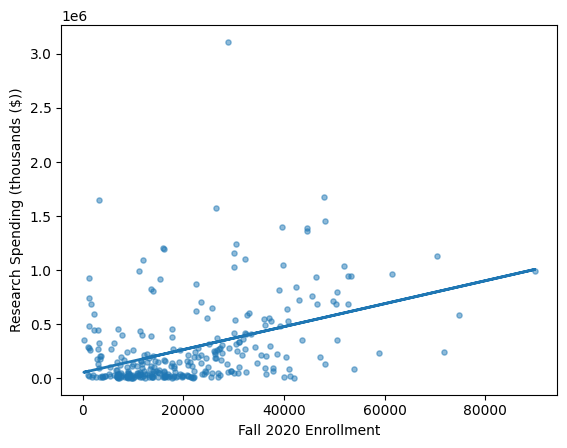

In [15]:
plt.scatter(x, y, s=14, alpha=.5)
plt.plot(x, yhat, linewidth=2)
plt.xlabel("Fall 2020 Enrollment")
plt.ylabel("Research Spending (thousands ($))")

In [17]:
model2 = LinearRegression()
model2.fit(d[["fallenr20","med_yn"]], y)

LinearRegression()

In [19]:
model2.coef_, model2.intercept_

(array([8.27837147e+00, 3.03058756e+05]), np.float64(-41621.64630693168))

In [20]:
model.coef_, model.intercept_

(array([10.61799654]), np.float64(53224.0057142553))

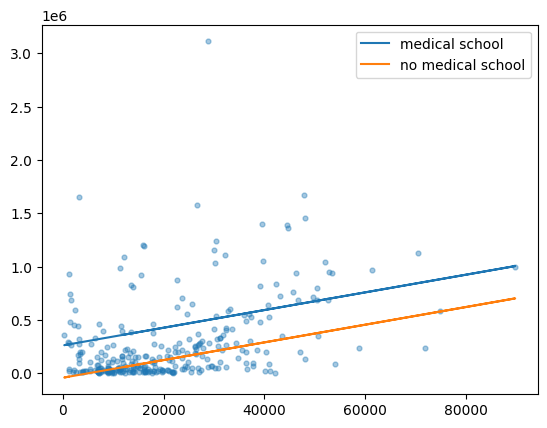

In [26]:
b0m,b1m,b2m = model2.intercept_, *model2.coef_
plt.scatter(x, y, s=12, alpha=.4)
plt.plot(x, b0m + b1m * x + b2m, label="medical school")
plt.plot(x, b0m + b1m * x, label="no medical school")
plt.legend()

In [28]:
bad = LinearRegression()
bad.fit(d[["fallenr20", "medical"]],y)
bad.coef_, bad.intercept_

(array([ 8.27837147e+00, -3.03058756e+05]), np.float64(564495.8666884332))

In [29]:
model2.coef_, model2.intercept_

(array([8.27837147e+00, 3.03058756e+05]), np.float64(-41621.64630693168))

In [42]:
yhat2 = model2.predict(d[["fallenr20","med_yn"]])
np.sqrt(np.mean((y - yhat2)**2))

np.float64(314589.93735226564)

In [43]:
from sklearn.metrics import r2_score
r2_score(y,yhat), r2_score(y,yhat2)

(0.1700943737660614, 0.3193169676075911)

In [44]:
r2_score(yhat2,y)

-1.13168450612653